# Neural Networks for Chemistry

# Install packages
only run if you do not have these packages installed

In [1]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install torch torchvision torchaudio #note this will install pytorch for CPU

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#note': Expected package name at the start of dependency specifier
    #note
    ^


# Loading data

In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs
import numpy as np

#method we will use to convert fingerprint to an array that can be used later with scikit learn
def mol_to_fp_array(mol, radius=2, nBits=2048):
    if mol is None:
        return None
    
    fpgen_morgan = AllChem.GetMorganGenerator(radius=radius,fpSize=nBits)
    fp = fpgen_morgan.GetFingerprint(mol)
    
    arr = np.zeros((nBits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

df = pd.read_csv("delaney.csv")

#let's set a log solubility of -2 as the cutoff between soluble and insoluble
df['soluble'] = df["measured log(solubility:mol/L)"] > -2

#calculate descriptors and add them to the dataframe
#Note - it can often help the model performance to scale the data within a standard range and/or to a normal distribution
#We will discuss how to do this in a future set of example code
df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df["hba"] = df["mol"].apply(lambda m: Descriptors.NumHAcceptors(m) if m is not None else pd.NA)
df["hbd"] = df["mol"].apply(lambda m: Descriptors.NumHDonors(m) if m is not None else pd.NA)
df["mw"] = df["mol"].apply(lambda m: Descriptors.MolWt(m) if m is not None else pd.NA)

#calculate fingerprints and add them to the dataframe

df["fp"] = df["mol"].apply(lambda m: mol_to_fp_array(m) if m is not None else pd.NA)

#this will let us see the beginning of the table
df.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,soluble,mol,hba,hbd,mw,fp
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,False,<rdkit.Chem.rdchem.Mol object at 0x0000027FA7D...,0,0,167.850,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,False,<rdkit.Chem.rdchem.Mol object at 0x0000027FA7D...,0,0,133.405,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,True,<rdkit.Chem.rdchem.Mol object at 0x0000027FA7D...,0,0,167.850,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,True,<rdkit.Chem.rdchem.Mol object at 0x0000027FA7F...,0,0,133.405,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,False,<rdkit.Chem.rdchem.Mol object at 0x0000027FA7F...,0,0,187.375,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# Classification Neural Network
We will set up a fully-connected neural network to classify solubility from fingerprint

Epoch  1 | Train Loss: 0.5671 | Train Acc: 0.6798 | Test Acc: 0.7205
Epoch  2 | Train Loss: 0.3354 | Train Acc: 0.8678 | Test Acc: 0.8166
Epoch  3 | Train Loss: 0.1556 | Train Acc: 0.9388 | Test Acc: 0.8603
Epoch  4 | Train Loss: 0.0677 | Train Acc: 0.9781 | Test Acc: 0.8559
Epoch  5 | Train Loss: 0.0326 | Train Acc: 0.9913 | Test Acc: 0.8603
Epoch  6 | Train Loss: 0.0246 | Train Acc: 0.9945 | Test Acc: 0.8603
Epoch  7 | Train Loss: 0.0174 | Train Acc: 0.9967 | Test Acc: 0.8559
Epoch  8 | Train Loss: 0.0132 | Train Acc: 0.9978 | Test Acc: 0.8559
Epoch  9 | Train Loss: 0.0102 | Train Acc: 0.9989 | Test Acc: 0.8690
Epoch 10 | Train Loss: 0.0105 | Train Acc: 0.9989 | Test Acc: 0.8603
Epoch 11 | Train Loss: 0.0096 | Train Acc: 0.9989 | Test Acc: 0.8559
Epoch 12 | Train Loss: 0.0058 | Train Acc: 0.9989 | Test Acc: 0.8515
Epoch 13 | Train Loss: 0.0083 | Train Acc: 0.9989 | Test Acc: 0.8603
Epoch 14 | Train Loss: 0.0091 | Train Acc: 0.9989 | Test Acc: 0.8734
Epoch 15 | Train Loss: 0.0066 | Tr

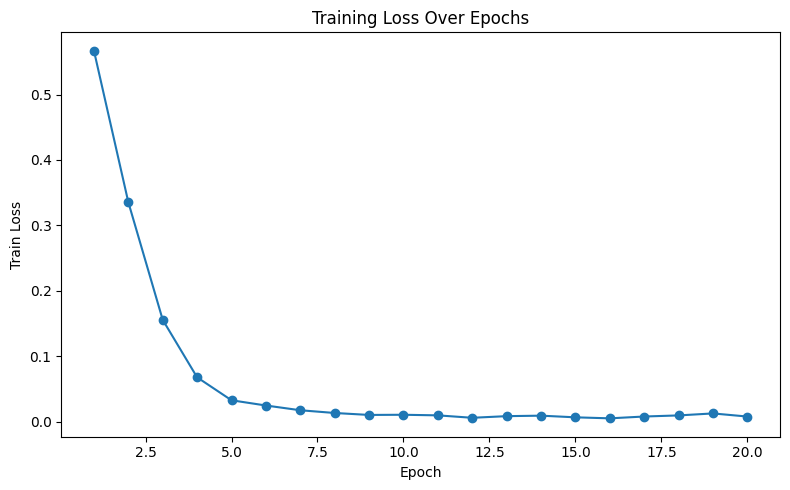

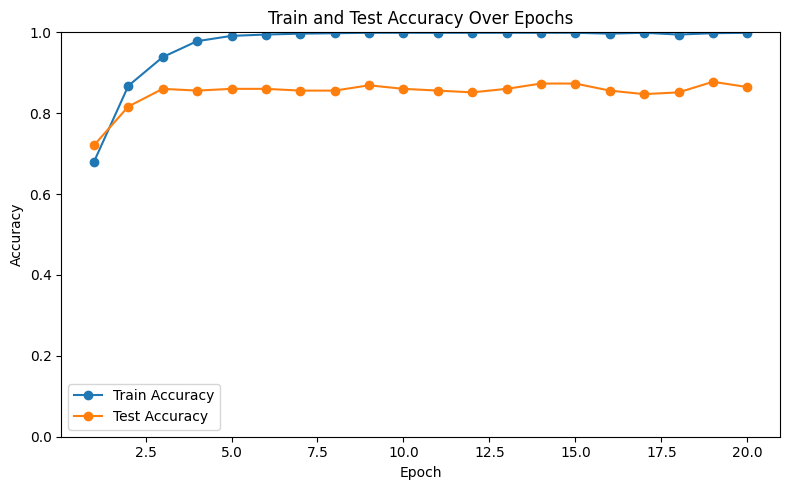

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#prepare data for pytorch
X = np.stack(df["fp"].values)   # shape: (n_samples, n_features)
y = df["soluble"].values.astype(np.float32)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

#split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#this class defines the neural network architecture
class BinaryFCNN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2):
        super().__init__()
        #nn.Sequential sets up each layer
        #Linear is a fully connected layer, arguments are input and output dimension
        #ReLU activation layers alternate until final output layer
        #to add more layers, just add more to the nn.Sequenquential list
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, 1)
        )
    
    #this will  run the model in the forward direction (make predictions)
    def forward(self, x):
        return self.model(x).squeeze(1)

input_dim = X.shape[1]
model = BinaryFCNN(input_dim=input_dim, hidden_dim1=256, hidden_dim2=128)

#set the loss (criterion), optimizer, and number of epochs
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

train_losses = []
train_accuracies = []
test_accuracies = []

#train the model
for epoch in range(num_epochs):
    #set model in train mode so weights can change
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward() #back propagation
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    
    #set model into eval mode, doesn't use dropout and use running statistics
    model.eval()
    test_correct = 0
    test_total = 0

    #turn off gradient, this will keep any weights from being accidently changed
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            test_correct += (preds == batch_y).sum().item()
            test_total += batch_y.size(0)

    test_acc = test_correct / test_total
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

# Plot train loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Over Epochs")
plt.tight_layout()
plt.show()

# Plot train and test accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), test_accuracies, marker='o', label="Test Accuracy")
plt.ylim(0,1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Test Accuracy Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Dropout
How overfit is our model? Dropout can help with overfitting by preventing the model from relying too much on individual neurons or specific combinations of neurons. Try changing the dropout rate hyperparameter and see how it affects the results.

Epoch  1 | Train Loss: 0.5911 | Train Acc: 0.6765 | Test Acc: 0.6769
Epoch  2 | Train Loss: 0.4102 | Train Acc: 0.7661 | Test Acc: 0.7860
Epoch  3 | Train Loss: 0.2305 | Train Acc: 0.9191 | Test Acc: 0.8210
Epoch  4 | Train Loss: 0.1114 | Train Acc: 0.9607 | Test Acc: 0.8515
Epoch  5 | Train Loss: 0.0565 | Train Acc: 0.9869 | Test Acc: 0.8646
Epoch  6 | Train Loss: 0.0321 | Train Acc: 0.9913 | Test Acc: 0.8646
Epoch  7 | Train Loss: 0.0306 | Train Acc: 0.9902 | Test Acc: 0.8559
Epoch  8 | Train Loss: 0.0163 | Train Acc: 0.9967 | Test Acc: 0.8646
Epoch  9 | Train Loss: 0.0126 | Train Acc: 0.9989 | Test Acc: 0.8734
Epoch 10 | Train Loss: 0.0099 | Train Acc: 0.9978 | Test Acc: 0.8603
Epoch 11 | Train Loss: 0.0115 | Train Acc: 0.9967 | Test Acc: 0.8559
Epoch 12 | Train Loss: 0.0094 | Train Acc: 0.9978 | Test Acc: 0.8603
Epoch 13 | Train Loss: 0.0135 | Train Acc: 0.9978 | Test Acc: 0.8690
Epoch 14 | Train Loss: 0.0086 | Train Acc: 0.9978 | Test Acc: 0.8603
Epoch 15 | Train Loss: 0.0079 | Tr

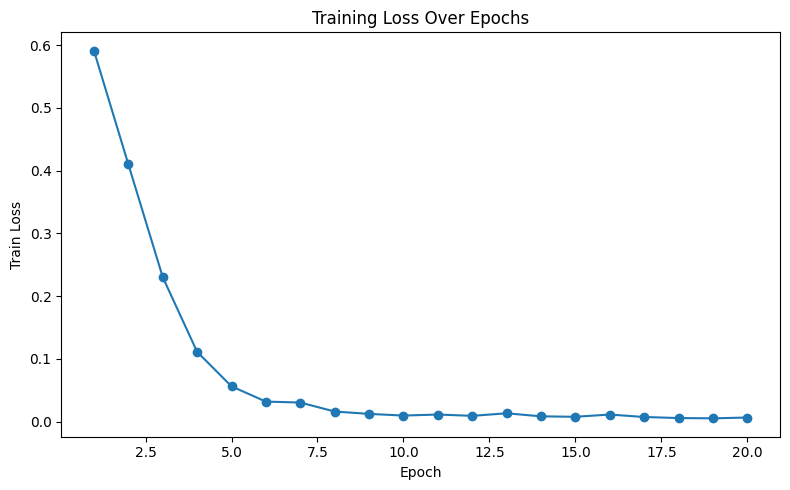

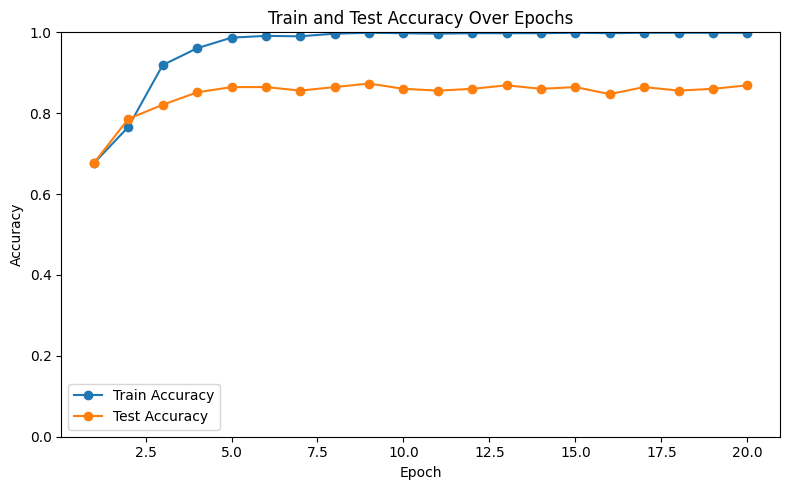

In [4]:
#this class defines the neural network architecture
class BinaryFCNN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.3):
        super().__init__()
        #nn.Sequential sets up each layer
        #Linear is a fully connected layer, arguments are input and output dimension
        #ReLU activation layers alternate until final output layer
        #to add more layers, just add more to the nn.Sequenquential list
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim2, 1)
        )
    
    #this will  run the model in the forward direction (make predictions)
    def forward(self, x):
        return self.model(x).squeeze(1)

input_dim = X.shape[1]
model = BinaryFCNN(input_dim=input_dim, hidden_dim1=256, hidden_dim2=128)

#set the loss (criterion), optimizer, and number of epochs
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

train_losses = []
train_accuracies = []
test_accuracies = []

#train the model
for epoch in range(num_epochs):
    #set model in train mode so weights can change
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward() #back propagation
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    
    #set model into eval mode, doesn't use dropout and use running statistics
    model.eval()
    test_correct = 0
    test_total = 0

    #turn off gradient, this will keep any weights from being accidently changed
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            test_correct += (preds == batch_y).sum().item()
            test_total += batch_y.size(0)

    test_acc = test_correct / test_total
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

# Plot train loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Over Epochs")
plt.tight_layout()
plt.show()

# Plot train and test accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), test_accuracies, marker='o', label="Test Accuracy")
plt.ylim(0,1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Test Accuracy Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Further analyze performance on test
Plot ROC and PRC curves

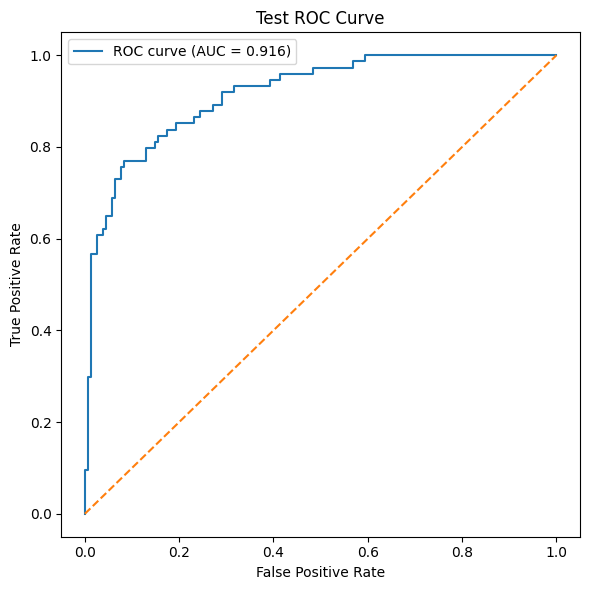

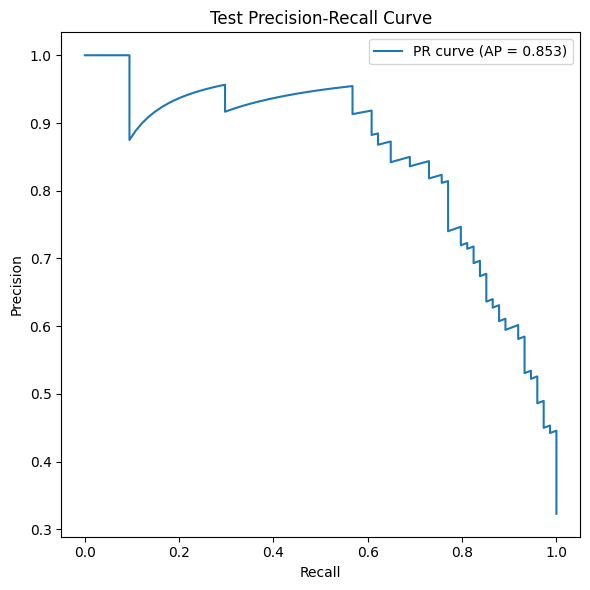

In [5]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

#remember to turn model into eval mode and use no_grad when applying model
model.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        logits = model(batch_X)                  # shape: (batch_size,)
        probs = torch.sigmoid(logits)            # convert logits to probabilities

        all_probs.extend(probs.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

# ROC curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-recall curve
precision, recall, _ = precision_recall_curve(all_true, all_probs)
ap = average_precision_score(all_true, all_probs)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Regression
Now let's rewrite the network so that it performs regression on the solubility rather than a classification

Epoch  1 | Train Loss: 3.2526 | Test Loss: 3.2325 | Train RMSE: 1.8035 | Test RMSE: 1.7979 | Train R2: 0.2607 | Test R2: 0.2577
Epoch  2 | Train Loss: 1.4114 | Test Loss: 1.6901 | Train RMSE: 1.1880 | Test RMSE: 1.3000 | Train R2: 0.6792 | Test R2: 0.6119
Epoch  3 | Train Loss: 0.9575 | Test Loss: 1.3980 | Train RMSE: 0.9785 | Test RMSE: 1.1824 | Train R2: 0.7824 | Test R2: 0.6790
Epoch  4 | Train Loss: 0.7146 | Test Loss: 1.2733 | Train RMSE: 0.8453 | Test RMSE: 1.1284 | Train R2: 0.8376 | Test R2: 0.7076
Epoch  5 | Train Loss: 0.5474 | Test Loss: 1.2297 | Train RMSE: 0.7399 | Test RMSE: 1.1089 | Train R2: 0.8756 | Test R2: 0.7176
Epoch  6 | Train Loss: 0.4356 | Test Loss: 1.1003 | Train RMSE: 0.6600 | Test RMSE: 1.0490 | Train R2: 0.9010 | Test R2: 0.7473
Epoch  7 | Train Loss: 0.3802 | Test Loss: 1.0690 | Train RMSE: 0.6166 | Test RMSE: 1.0339 | Train R2: 0.9136 | Test R2: 0.7545
Epoch  8 | Train Loss: 0.4056 | Test Loss: 1.0859 | Train RMSE: 0.6369 | Test RMSE: 1.0421 | Train R2: 0

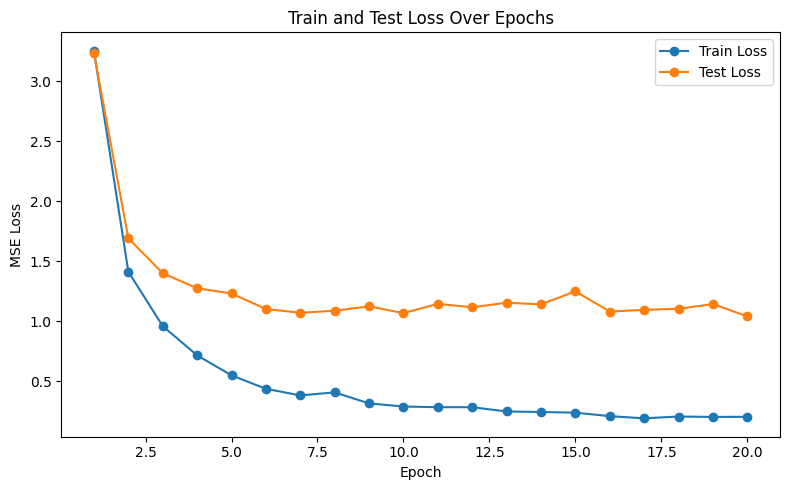

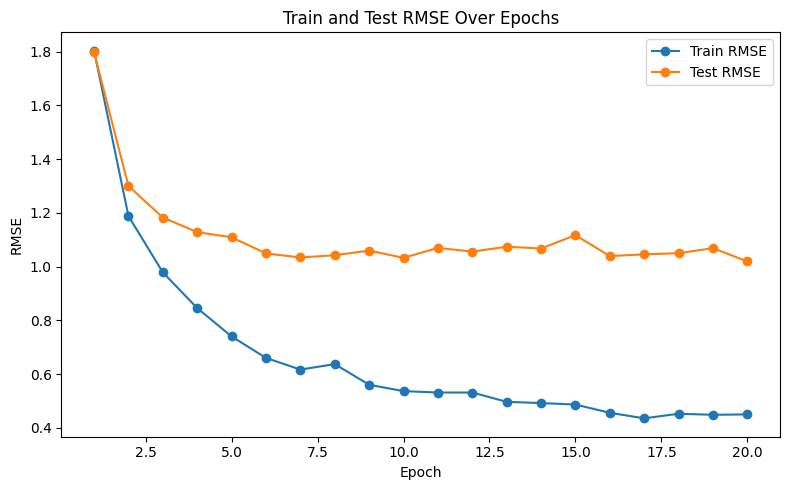

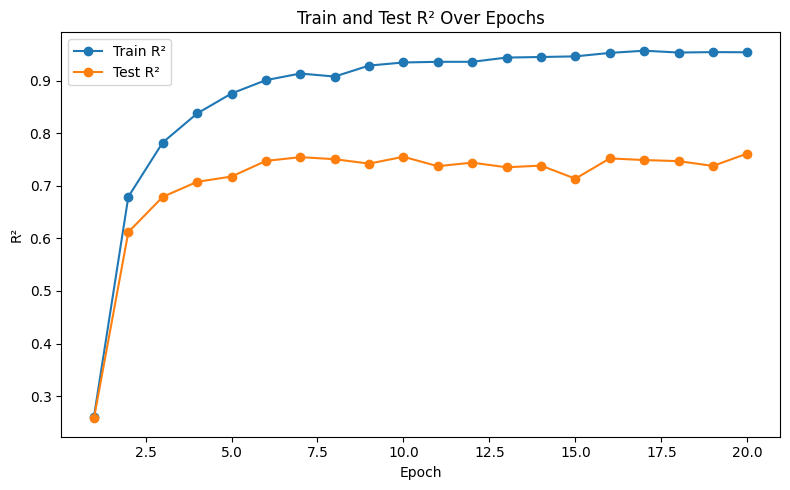

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

#prepare data for pytorch
X = np.stack(df["fp"].values)   # shape: (n_samples, n_features)
y = df["measured log(solubility:mol/L)"].values.astype(np.float32)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

#split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class RegressionFCNN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(1)


input_dim = X.shape[1]

model = RegressionFCNN(
    input_dim=input_dim,
    hidden_dim1=256,
    hidden_dim2=128,
    dropout_rate=0.3
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

train_losses = []
test_losses = []

train_rmses = []
test_rmses = []

train_r2s = []
test_r2s = []


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        total += batch_X.size(0)

    train_loss = running_loss / total

    # Evaluate on full training set
    model.eval()
    train_eval_loss = 0.0
    train_eval_total = 0
    train_preds = []
    train_true = []

    with torch.no_grad():
        for batch_X, batch_y in train_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            train_eval_loss += loss.item() * batch_X.size(0)
            train_eval_total += batch_X.size(0)

            train_preds.extend(predictions.cpu().numpy())
            train_true.extend(batch_y.cpu().numpy())

    train_eval_loss = train_eval_loss / train_eval_total
    train_rmse = np.sqrt(mean_squared_error(train_true, train_preds))
    train_r2 = r2_score(train_true, train_preds)

    # Evaluate on test set
    test_running_loss = 0.0
    test_total = 0
    test_preds = []
    test_true = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            test_running_loss += loss.item() * batch_X.size(0)
            test_total += batch_X.size(0)

            test_preds.extend(predictions.cpu().numpy())
            test_true.extend(batch_y.cpu().numpy())

    test_loss = test_running_loss / test_total
    test_rmse = np.sqrt(mean_squared_error(test_true, test_preds))
    test_r2 = r2_score(test_true, test_preds)

    train_losses.append(train_eval_loss)
    test_losses.append(test_loss)

    train_rmses.append(train_rmse)
    test_rmses.append(test_rmse)

    train_r2s.append(train_r2)
    test_r2s.append(test_r2)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {train_eval_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Train RMSE: {train_rmse:.4f} | "
        f"Test RMSE: {test_rmse:.4f} | "
        f"Train R2: {train_r2:.4f} | "
        f"Test R2: {test_r2:.4f}"
    )

# Plot train and test loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label="Train Loss")
plt.plot(range(1, num_epochs + 1), test_losses, marker='o', label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train and Test Loss Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Plot train and test RMSE
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_rmses, marker='o', label="Train RMSE")
plt.plot(range(1, num_epochs + 1), test_rmses, marker='o', label="Test RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Train and Test RMSE Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# Plot train and test R2
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_r2s, marker='o', label="Train R²")
plt.plot(range(1, num_epochs + 1), test_r2s, marker='o', label="Test R²")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.title("Train and Test R² Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()


# More Performance Analysis
plot actual vs predicted for regression task

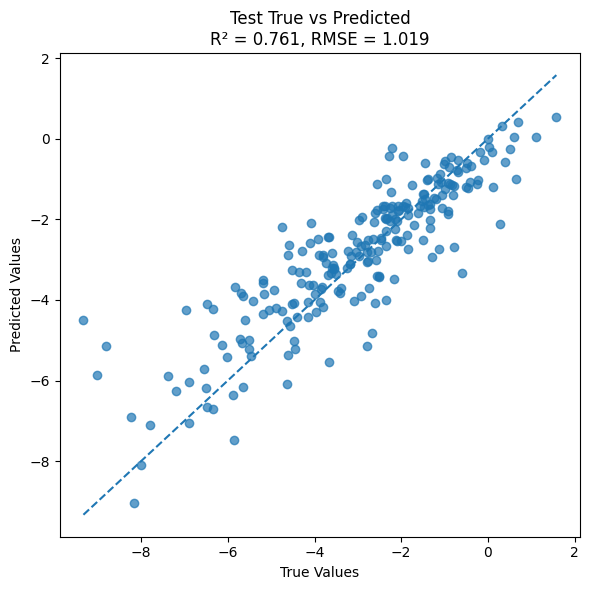

In [7]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

r2 = r2_score(all_true, all_preds)
rmse = np.sqrt(mean_squared_error(all_true, all_preds))

plt.figure(figsize=(6, 6))
plt.scatter(all_true, all_preds, alpha=0.7)

min_val = min(all_true.min(), all_preds.min())
max_val = max(all_true.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Test True vs Predicted\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.tight_layout()
plt.show()
